# setup

In [ ]:
# imports
import csv
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [ ]:
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#F44336']

def find_plateau(vals):
    """
    Finds the first epoch where the validation perplexity plateaus (i.e. does not improve for 3 consecutive epochs).
    Args:
        vals (pd.Series): A pandas Series containing the validation perplexity values indexed by epoch.
    Returns:
        int or None: The epoch number where the plateau starts, or None if no plateau is found.
    """
    vals = vals.astype(float)
    for j in range(1, len(vals)):
        if vals.iloc[j] == vals.iloc[j-1] and all(vals.iloc[j:] == vals.iloc[j]):
            return vals.index[j-1]
    return None

def highlight_plateau(df):
    """
    Highlights the plateau epochs in the DataFrame by applying a background color to the corresponding cells.
    Args:
        df (pd.DataFrame): A pandas DataFrame containing the validation perplexity values indexed by epoch and dropout.
    Returns:
        pd.DataFrame: A DataFrame with the same shape as the input, where the cells corresponding to plateau epochs are styled with a background color.
    """
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for i, col in enumerate(df.columns):
        plateau_epoch = find_plateau(df[col])
        if plateau_epoch:
            styles.iloc[df.index.get_loc(plateau_epoch), i] = f'background-color: {colors[i]}40'
    return styles

### if necessary, change files path in line 11

In [ ]:
def create_df(ppl_of_interest):
    """
    Creates a DataFrame with the perplexity values for the specified ppl_of_interest (e.g., 'valid_ppl' or 'testing') across different dropout rates and epochs.

    Args:
        ppl_of_interest (str): The column name in the CSV files that contains the perplexity values to be extracted ('valid_ppl' or 'test' or 'train_ppl').

    Returns:
        pd.DataFrame: A DataFrame where rows correspond to epochs and columns correspond to different dropout rates, containing the perplexity values for the specified ppl_of_interest.
    """
    files = sorted(glob.glob('../logs/dropout_*.csv'))  # change the path if your logs are in a different directory :)
    dropouts = [os.path.basename(f).replace('dropout_', '').replace('.csv', '') for f in files]
    headers = [f'dropout_{d}' for d in dropouts]
    results = {}
    for f, label in zip(files, headers):
        with open(f) as fh:
            for row in csv.DictReader(fh):
                epoch = row['epoch']
                if ppl_of_interest == 'test' and epoch != 'test':
                    continue
                if ppl_of_interest != 'test' and epoch == 'test':
                    continue
                epoch = epoch if epoch == 'test' else int(epoch)
                col = 'valid_ppl' if ppl_of_interest == 'test' else ppl_of_interest
                results.setdefault(epoch, {})[label] = row[col]
    df = pd.DataFrame.from_dict(results, orient='index')[headers]
    df.index.name = f'epoch of {ppl_of_interest}'
    return df, dropouts

In [ ]:
def create_plot(df, dropouts, title):
    """
    Creates a line plot of the perplexity values across epochs for different dropout rates, and highlights the plateau epochs.
    Args:
        df (pd.DataFrame): A DataFrame containing the perplexity values indexed by epoch and dropout.
        dropouts (list): A list of dropout rates corresponding to the columns in the DataFrame.
        title (str): The title of the plot.
    Returns:
        None: Displays the plot!!
    """
    fig, ax = plt.subplots(figsize=(20, 8))
    labels = []
    for dropout, color in zip(dropouts, colors):
        col = f'dropout_{dropout}'
        vals = df[col].astype(float)
        ax.plot(df.index, vals, label=f'Dropout {float(dropout)/10:.1f}',
                color=color, linewidth=1.5, marker='o', markersize=3)

        plateau_epoch = find_plateau(vals)
        if plateau_epoch:
            ax.axvline(x=plateau_epoch, color=color, linestyle='-', linewidth=1, alpha=0.8)
            labels.append((plateau_epoch, vals[plateau_epoch] * 3, f'→ epoch {plateau_epoch}', color))

    adjusted_y = [labels[0][1]]
    for i in range(1, len(labels)):
        new_y = min(labels[i][1], adjusted_y[-1] - 10)
        adjusted_y.append(new_y)
    for (epoch, _, text, color), y in zip(labels, adjusted_y):
        ax.text(epoch + 0.2, y, text, color=color, fontsize=9, va='center')

    ax.set_xlabel('Epoch', fontsize=13)
    ax.set_ylabel('Perplexity', fontsize=13)
    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.legend(fontsize=11, frameon=True)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
    plt.tight_layout()
    plt.show()

# tables

### training

In [7]:
train_df, train_dropouts = create_df('train_ppl')
train_df.style.apply(highlight_plateau, axis=None)

,dropout_00,dropout_04,dropout_05,dropout_06,dropout_07
epoch of train_ppl,,,,,
1,353.3375,351.1072,366.6375,358.6176,375.5144
2,90.1919,99.0837,99.9180,104.0190,114.4443
3,58.7729,66.2494,69.6528,73.8308,80.5960
4,46.9627,54.7335,58.6505,62.9729,69.5872
5,39.9611,48.0492,52.4149,56.6335,63.7207
6,34.5104,43.5981,48.1050,52.3873,60.0055
7,30.0023,39.9405,44.7797,49.3974,57.5983
8,21.8417,37.1728,41.8683,47.0653,55.4279
9,19.3817,34.6628,39.5007,44.6851,53.5410


### validity

In [8]:
valid_df, valid_dropouts = create_df('valid_ppl')
valid_df.style.apply(highlight_plateau, axis=None)

,dropout_00,dropout_04,dropout_05,dropout_06,dropout_07
epoch of valid_ppl,,,,,
1,146.0436,143.5860,141.5030,151.8568,166.1525
2,75.4451,79.8427,79.1240,81.3377,92.1667
3,63.0860,64.1958,63.9771,68.0532,77.8525
4,58.1050,57.9182,57.5716,61.0381,69.7256
5,55.2906,54.1774,54.5436,57.3966,64.2281
6,55.1096,51.1675,52.1452,54.6478,61.1553
7,56.0022,49.7332,50.0489,54.0248,60.4900
8,50.2942,48.5636,49.1042,52.9654,57.9525
9,51.8101,48.4626,48.4621,52.2733,56.5324


### testing

In [9]:
test_df, test_dropouts = create_df('test')
test_df

,dropout_00,dropout_04,dropout_05,dropout_06,dropout_07
epoch of test,,,,,
test,47.9860,42.0308,42.5432,44.5721,48.2970


# plotting

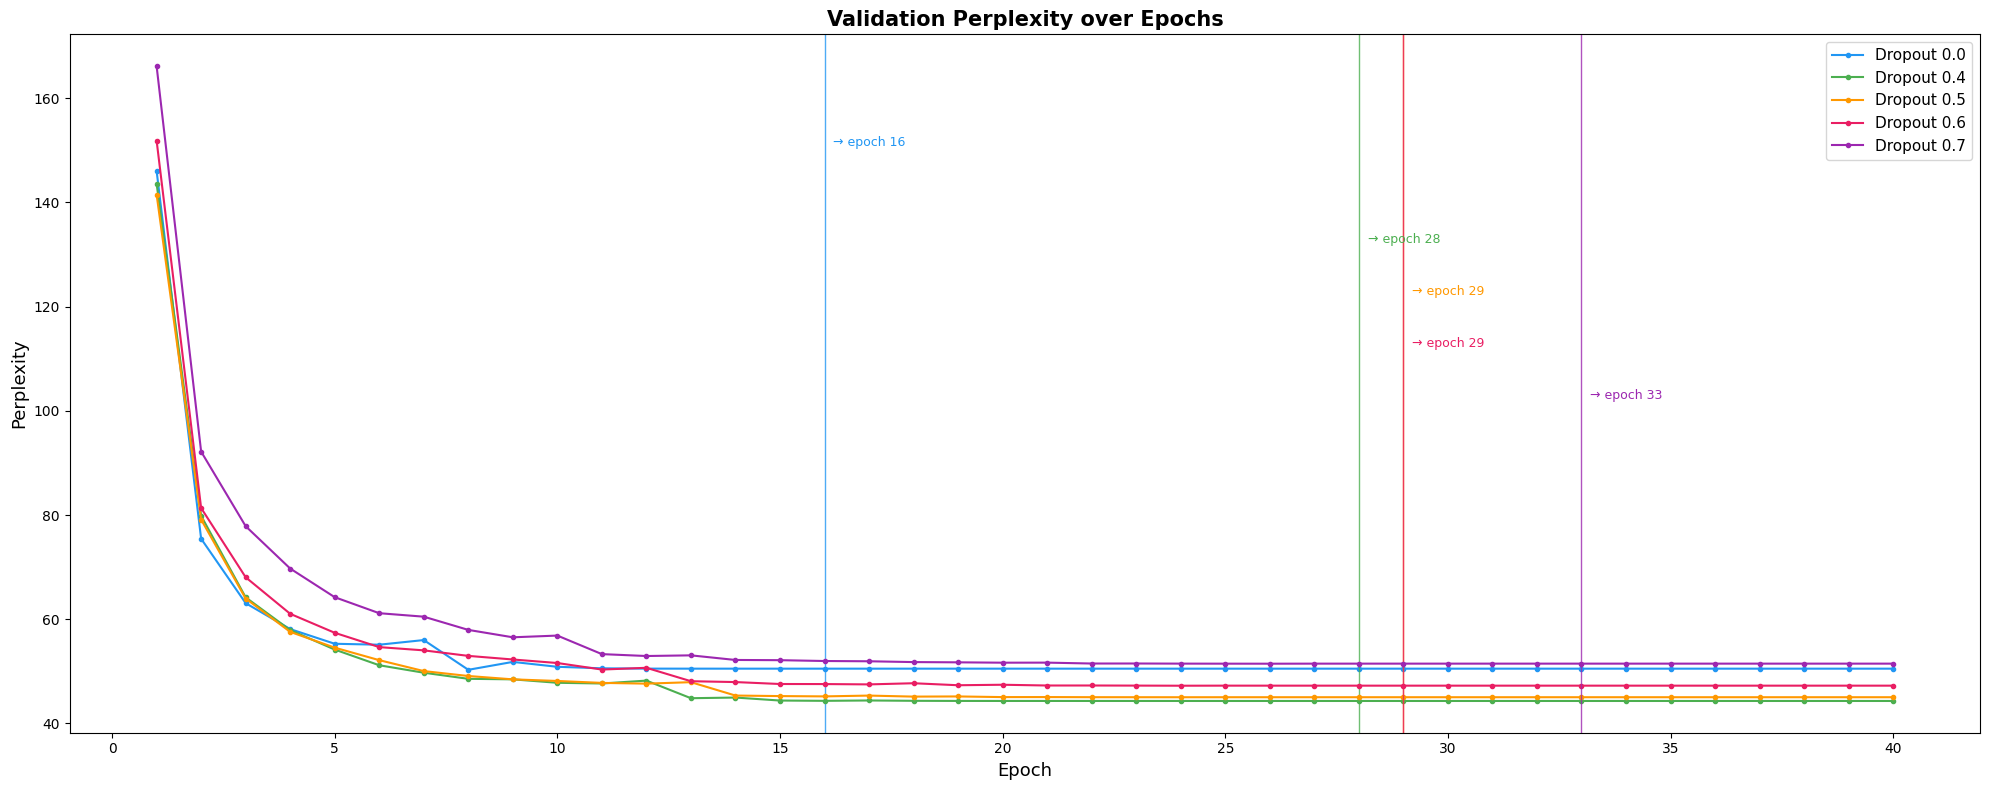

In [10]:
create_plot(valid_df, valid_dropouts, 'Validation Perplexity over Epochs')

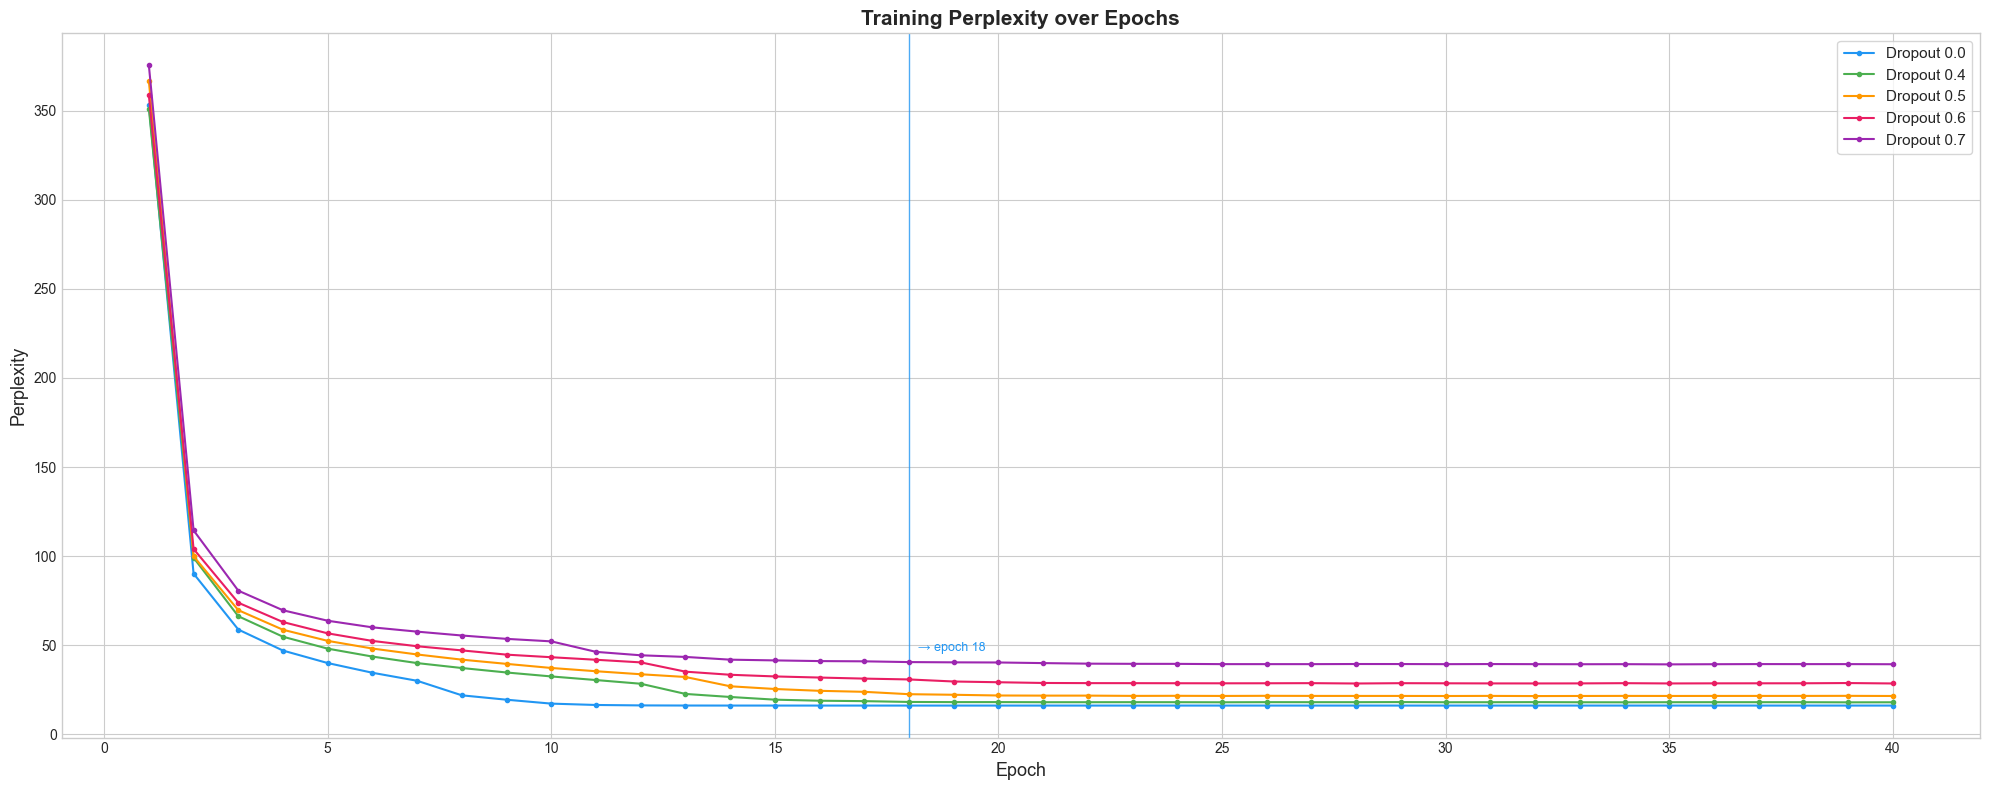

In [157]:
create_plot(train_df, train_dropouts, 'Training Perplexity over Epochs')

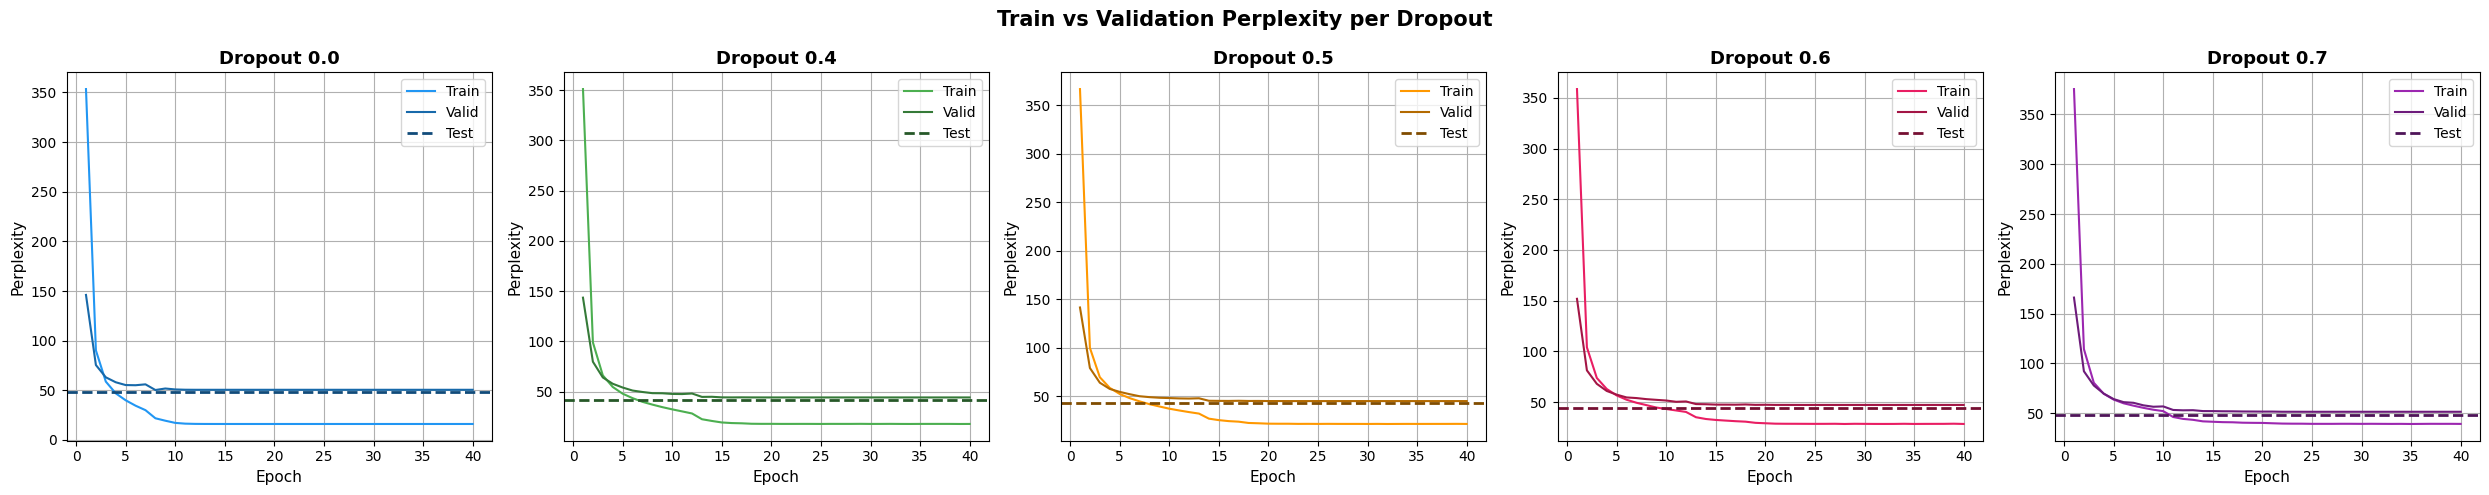

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
axes = axes.flatten()
dropouts = [col.replace('dropout_', '') for col in train_df.columns]

for i, dropout in enumerate(dropouts):
    col = f'dropout_{dropout}'
    ax = axes[i]
    
    base_color = colors[i]
    
    # darker variants bc all same color was hard to read :(
    train_color = base_color
    valid_color = mcolors.to_rgba(base_color)
    valid_color = tuple([c*0.7 for c in valid_color[:3]] + [valid_color[3]])
    test_color = mcolors.to_rgba(base_color)
    test_color = tuple([c*0.5 for c in test_color[:3]] + [test_color[3]])
    
    ax.plot(train_df.index, train_df[col].astype(float), label='Train', color=train_color, linewidth=1.5)
    ax.plot(valid_df.index, valid_df[col].astype(float), label='Valid', color=valid_color, linewidth=1.5)
    
    test_value = test_df[col].astype(float).iloc[0]
    ax.axhline(y=test_value, color=test_color, linestyle='--', linewidth=2, label='Test')
    
    ax.set_title(f'Dropout {float(dropout)/10:.1f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Perplexity', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True)

plt.suptitle('Train vs Validation Perplexity per Dropout', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()